In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os, sys
import torch

PROJECT_ROOT = "/content/drive/MyDrive/Explainable Detection of Online Sexism"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
os.environ["EDOS_CONFIG"] = "/content/drive/MyDrive/Explainable Detection of Online Sexism/config/config.yaml"

from src.pipeline import setup, run_rnn_binary, run_rnn_category, run_transformer_binary, run_transformer_category
from config.config import (
    DATA_PATH, GLOVE_PATH, EMBED_DIM, MAX_VOCAB, MAX_LEN, HIDDEN_DIM, BATCH_SIZE, BATCH_SIZE_TRANSFORMER,
    MODEL_NAME, TRANSFORMER_MAX_LEN, EPOCHS, PATIENCE, USE_FOCAL, FOCAL_GAMMA, BINARY_LABELS, CATEGORY_LABELS,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
state = setup(device)

print(f"Data        : {DATA_PATH}")
print(f"GloVe       : {GLOVE_PATH}")
print(f"Embed dim   : {EMBED_DIM}")
print(f"Transformer : {MODEL_NAME}")
print(f"Epochs      : {EPOCHS}  |  Patience: {PATIENCE}")
print(f"Use Focal   : {USE_FOCAL}  |  gamma: {FOCAL_GAMMA}")

Mounted at /content/drive
Device: cuda
Loading data ...
Binary   — train: 16000  test: 4000
Category — train: 3884  test: 970

Building vocab + loading GloVe ...
Vocabulary size: 20000
GloVe coverage: 17294 / 20000 ( 86.5%)

Building RNN loaders ...
Building Transformer loaders ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Binary weights  : tensor([0.6603, 2.0597], device='cuda:0')
Category weights: tensor([2.7429, 0.5344, 0.7290, 2.5486], device='cuda:0')
Data        : /content/drive/MyDrive/Explainable Detection of Online Sexism/Dataset/edos_clean.csv
GloVe       : /content/drive/MyDrive/Explainable Detection of Online Sexism/GloVe/glove.twitter.27B.200d.txt
Embed dim   : 200
Transformer : roberta-base
Epochs      : 20  |  Patience: 4
Use Focal   : True  |  gamma: 2.0



BiLSTM — Task A (Binary)
Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


1      0.1639     0.4762    0.4759    0.5863    0.5776    LR: 1.00e-03


2      0.1250     0.6822    0.6641    0.6105    0.6003    LR: 1.00e-03


3      0.0979     0.7729    0.7483    0.6870    0.6612    LR: 1.00e-03


4      0.0680     0.8625    0.8373    0.7542    0.7141    LR: 1.00e-03


5      0.0442     0.9207    0.9009    0.7880    0.7378    LR: 1.00e-03


6      0.0289     0.9538    0.9404    0.7640    0.7163    LR: 1.00e-03


7      0.0222     0.9681    0.9582    0.7937    0.7344    LR: 1.00e-03


8      0.0185     0.9722    0.9634    0.7450    0.6964    LR: 5.00e-04


9      0.0104     0.9859    0.9812    0.7957    0.7320    LR: 5.00e-04

Early stopping triggered

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Not sexist       0.88      0.85      0.86      3030
      Sexist       0.57      0.64      0.60       970

    accuracy                           0.80      4000
   macro avg       0.72      0.74      0.73      4000
weighted avg       0.80      0.80      0.80      4000

Accuracy : 0.7957
Macro F1 : 0.7320
Weighted F1 : 0.7993

Confusion Matrix (raw):
[[2567  463]
 [ 354  616]]


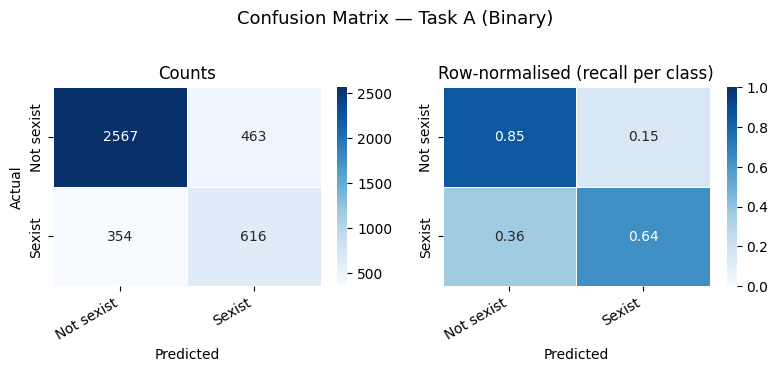

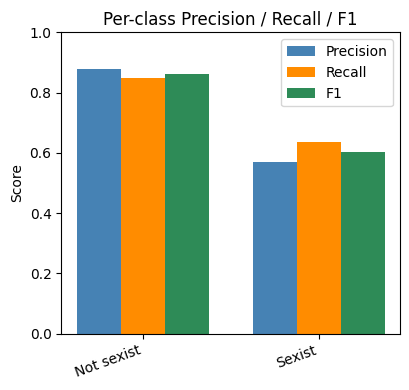


ERROR ANALYSIS

Total errors: 817 / 4000 (20.4%)

Error rate per true class:


,class,errors,total,error_rate (%)
1,Sexist,354,970,36.5
0,Not sexist,463,3030,15.3



Top confusion pairs (actual → predicted):


,actual,predicted,count
0,Not sexist,Sexist,463
1,Sexist,Not sexist,354


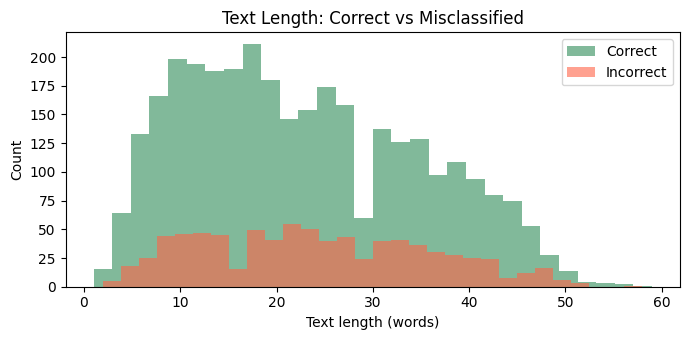


Sample misclassified examples:

  ✗ Actual: [Not sexist]  →  Predicted: [Sexist]  (n = 463)
    • (0.80) if your daughter is socializing with blacks, and visiting black areas, and partying around blacks - then the fact she ha
    • (0.90) you mean those videos where a woman slaps a guy when she's fucked up? we see those everyday already.
    • (0.90) true, most do lol i get hit on by more fat girls than anything else. but they usually settle for an out of shape guy. fi

  ✗ Actual: [Sexist]  →  Predicted: [Not sexist]  (n = 354)
    • (0.97) well then good because someone has to knock her ass back in line when she acts like a woman and posts bullshit about her
    • (0.52) yes, normal women want to be dominated. social scientists call it female hypergamy. and it is why women make bad bosses 
    • (0.96) i would pay to see her ass cracker. #nsfw

Results logged → /content/drive/MyDrive/Explainable Detection of Online Sexism/results/results_binary.csv


In [2]:
rnn_binary = run_rnn_binary(state, device)


BiLSTM — Task B (Category)
Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


1      0.8537     0.1383    0.1323    0.1722    0.1678    LR: 1.00e-03


2      0.6451     0.2974    0.2939    0.3639    0.3584    LR: 1.00e-03


3      0.4797     0.4148    0.4188    0.3979    0.3747    LR: 1.00e-03


4      0.3499     0.4809    0.5093    0.4000    0.3847    LR: 1.00e-03


...

7      0.1181     0.6220    0.7321    0.4691    0.4519    LR: 1.00e-03


8      0.0785     0.6421    0.7555    0.4144    0.3899    LR: 1.00e-03


9      0.0652     0.6823    0.7878    0.4206    0.4008    LR: 1.00e-03


10     0.0555     0.7057    0.8042    0.4392    0.4063    LR: 5.00e-04


11     0.0384     0.7837    0.8613    0.4309    0.4118    LR: 5.00e-04

Early stopping triggered

CLASSIFICATION REPORT
                       precision    recall  f1-score   support

              Threats       0.42      0.54      0.48        89
           Derogation       0.49      0.33      0.39       454
            Animosity       0.39      0.60      0.48       333
Prejudiced Discussion       0.48      0.22      0.30        94

             accuracy                           0.43       970
            macro avg       0.45      0.42      0.41       970
         weighted avg       0.45      0.43      0.42       970

Accuracy : 0.4309
Macro F1 : 0.4118
Weighted F1 : 0.4200

Confusion Matrix (raw):
[[ 48  18  21   2]
 [ 33 148 257  16]
 [ 17 110 201   5]
 [ 15  24  34  21]]


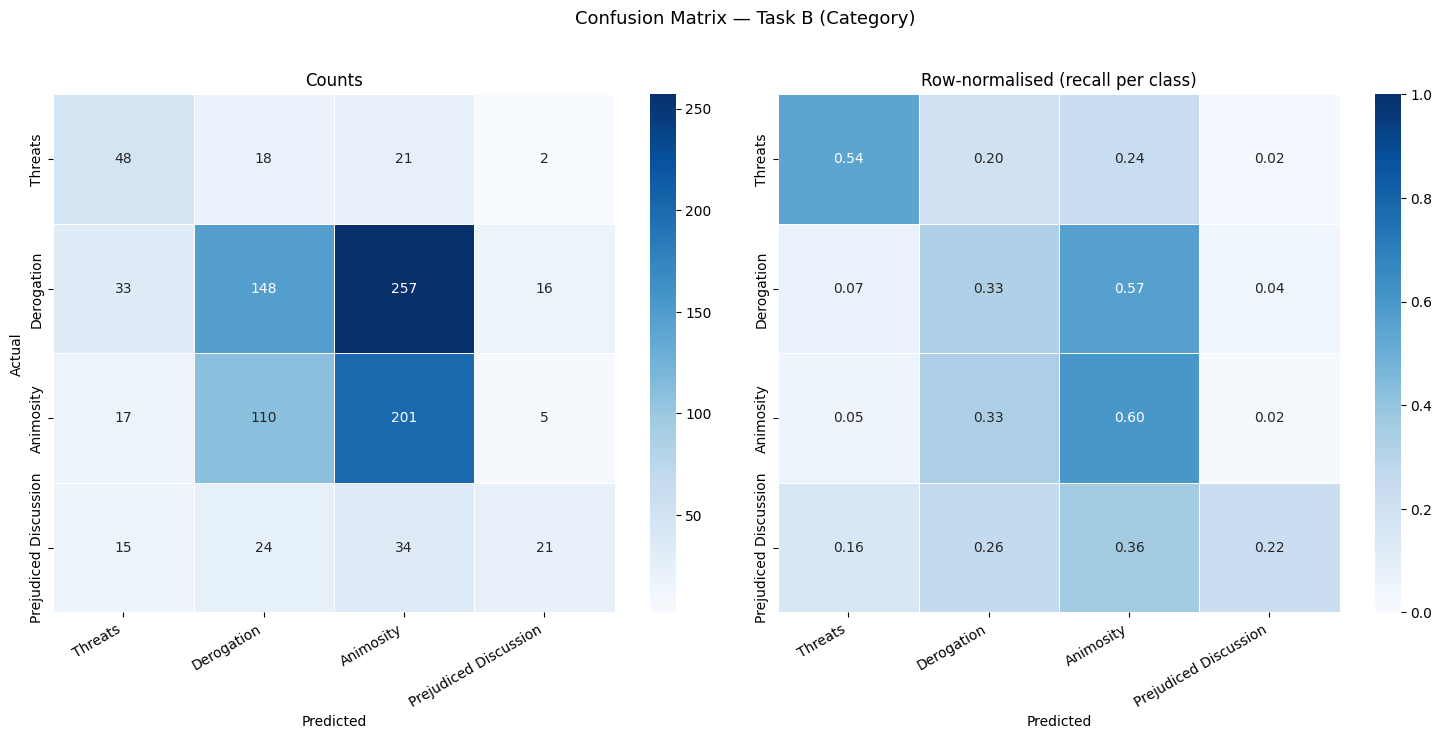

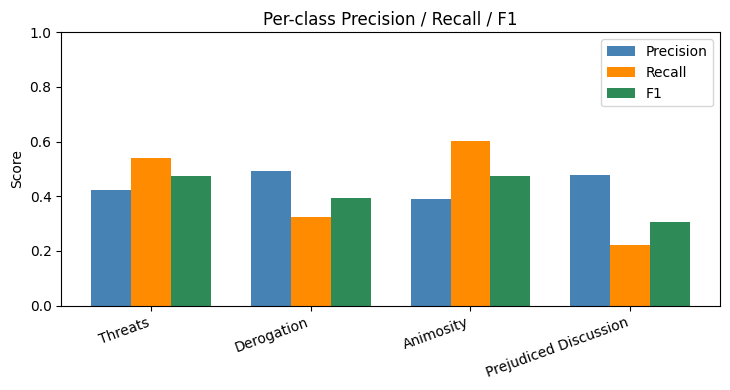


ERROR ANALYSIS

Total errors: 552 / 970 (56.9%)

Error rate per true class:


,class,errors,total,error_rate (%)
3,Prejudiced Discussion,73,94,77.7
1,Derogation,306,454,67.4
0,Threats,41,89,46.1
2,Animosity,132,333,39.6



Top confusion pairs (actual → predicted):


,actual,predicted,count
3,Derogation,Animosity,257
0,Animosity,Derogation,110
6,Prejudiced Discussion,Animosity,34
5,Derogation,Threats,33
7,Prejudiced Discussion,Derogation,24
9,Threats,Animosity,21
10,Threats,Derogation,18
2,Animosity,Threats,17
4,Derogation,Prejudiced Discussion,16
8,Prejudiced Discussion,Threats,15


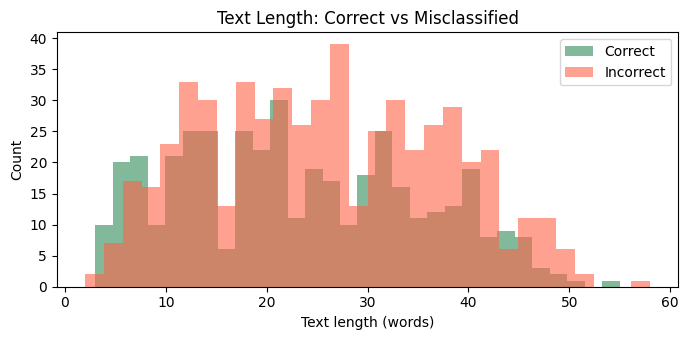


Sample misclassified examples:

  ✗ Actual: [Derogation]  →  Predicted: [Animosity]  (n = 257)
    • (0.39) well then good because someone has to knock her ass back in line when she acts like a woman and posts bullshit about her
    • (0.62) yes, normal women want to be dominated. social scientists call it female hypergamy. and it is why women make bad bosses 
    • (0.53) imagine the woman you find most attractive in the world, she would let him fuck her in the ass on their first date. ther

  ✗ Actual: [Animosity]  →  Predicted: [Derogation]  (n = 110)
    • (0.58) most here would fuck her.
    • (0.53) #feminist looks to have sex with #nazis on #tinder. she even is a vegetarian, and an artist just like #hitler was! does 
    • (0.57) but don't you miss having a first lady that could beat most men in a bar brawl.or at least b.o.michael.i mean michelle.o

  ✗ Actual: [Prejudiced Discussion]  →  Predicted: [Animosity]  (n = 34)
    • (0.51) paul still can not get it. islam and feminis

In [3]:
rnn_category = run_rnn_category(state, device)


roberta-base — Task A (Binary)


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


...

11     0.0101     0.9942    0.9922    0.8775    0.8364    LR: 1.00e-05


12     0.0087     0.9949    0.9930    0.8758    0.8354    LR: 8.89e-06


13     0.0089     0.9951    0.9933    0.8715    0.8332    LR: 7.78e-06


14     0.0047     0.9974    0.9964    0.8780    0.8334    LR: 6.67e-06


15     0.0056     0.9968    0.9956    0.8790    0.8356    LR: 5.56e-06

Early stopping triggered

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Not sexist       0.92      0.92      0.92      3030
      Sexist       0.75      0.75      0.75       970

    accuracy                           0.88      4000
   macro avg       0.84      0.84      0.84      4000
weighted avg       0.88      0.88      0.88      4000

Accuracy : 0.8790
Macro F1 : 0.8356
Weighted F1 : 0.8791

Confusion Matrix (raw):
[[2786  244]
 [ 240  730]]


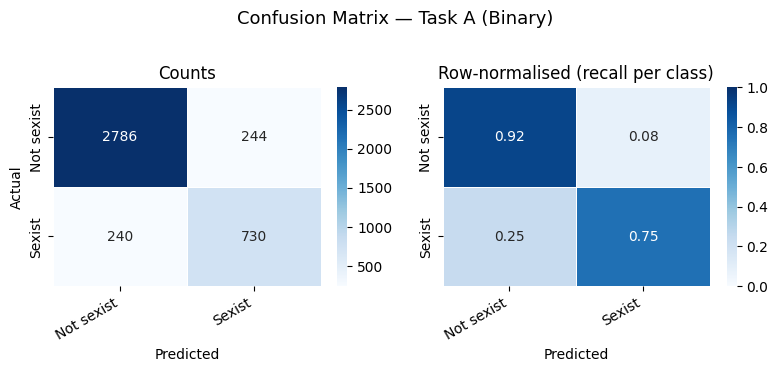

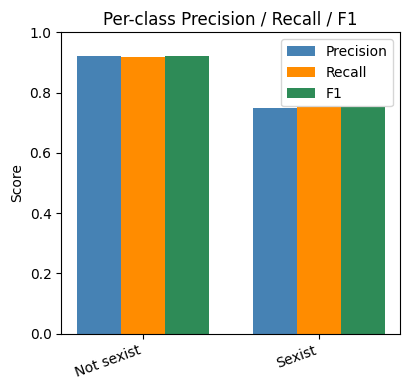


ERROR ANALYSIS

Total errors: 484 / 4000 (12.1%)

Error rate per true class:


,class,errors,total,error_rate (%)
1,Sexist,240,970,24.7
0,Not sexist,244,3030,8.1



Top confusion pairs (actual → predicted):


,actual,predicted,count
0,Not sexist,Sexist,244
1,Sexist,Not sexist,240


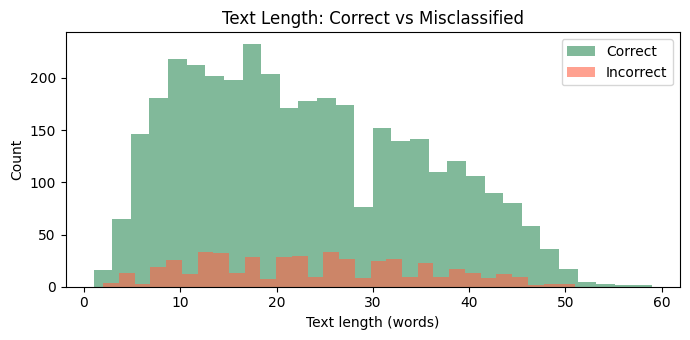


Sample misclassified examples:

  ✗ Actual: [Not sexist]  →  Predicted: [Sexist]  (n = 244)
    • (0.98) most men know instinctually the game. but their ego's are so fucking big that they think, not mine, not me. bang bang sh
    • (0.99) little girls in globalist “refugee” camps are bought and sold by men pretending to be their fathers, who rape them and u
    • (0.94) welcome to gender equality. suck it!

  ✗ Actual: [Sexist]  →  Predicted: [Not sexist]  (n = 240)
    • (0.99) i would pay to see her ass cracker. #nsfw
    • (0.99) 10/10 with interior decorating skills like yours, girls will be falling all over you. i'm falling for you a little mysel
    • (0.98) isn't it convenient that she doesn't have the video of this guy threatening to kill her! she films every moment of her l

Results logged → /content/drive/MyDrive/Explainable Detection of Online Sexism/results/results_binary.csv


In [4]:
tf_binary = run_transformer_binary(state, device)


roberta-base — Task B (Category)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


1      0.8838     0.1269    0.1169    0.1557    0.1757    LR: 1.00e-05


...

11     0.0204     0.9040    0.9365    0.6351    0.6237    LR: 1.00e-05


12     0.0158     0.9292    0.9530    0.6268    0.6220    LR: 8.89e-06


13     0.0137     0.9565    0.9687    0.6227    0.6162    LR: 7.78e-06


14     0.0083     0.9691    0.9798    0.6258    0.6190    LR: 6.67e-06


15     0.0052     0.9802    0.9865    0.6186    0.6045    LR: 5.56e-06

Early stopping triggered

CLASSIFICATION REPORT
                       precision    recall  f1-score   support

              Threats       0.68      0.71      0.69        89
           Derogation       0.62      0.75      0.68       454
            Animosity       0.63      0.43      0.51       333
Prejudiced Discussion       0.51      0.55      0.53        94

             accuracy                           0.62       970
            macro avg       0.61      0.61      0.60       970
         weighted avg       0.62      0.62      0.61       970

Accuracy : 0.6186
Macro F1 : 0.6045
Weighted F1 : 0.6097

Confusion Matrix (raw):
[[ 63  16   5   5]
 [ 17 342  68  27]
 [  9 164 143  17]
 [  4  26  12  52]]


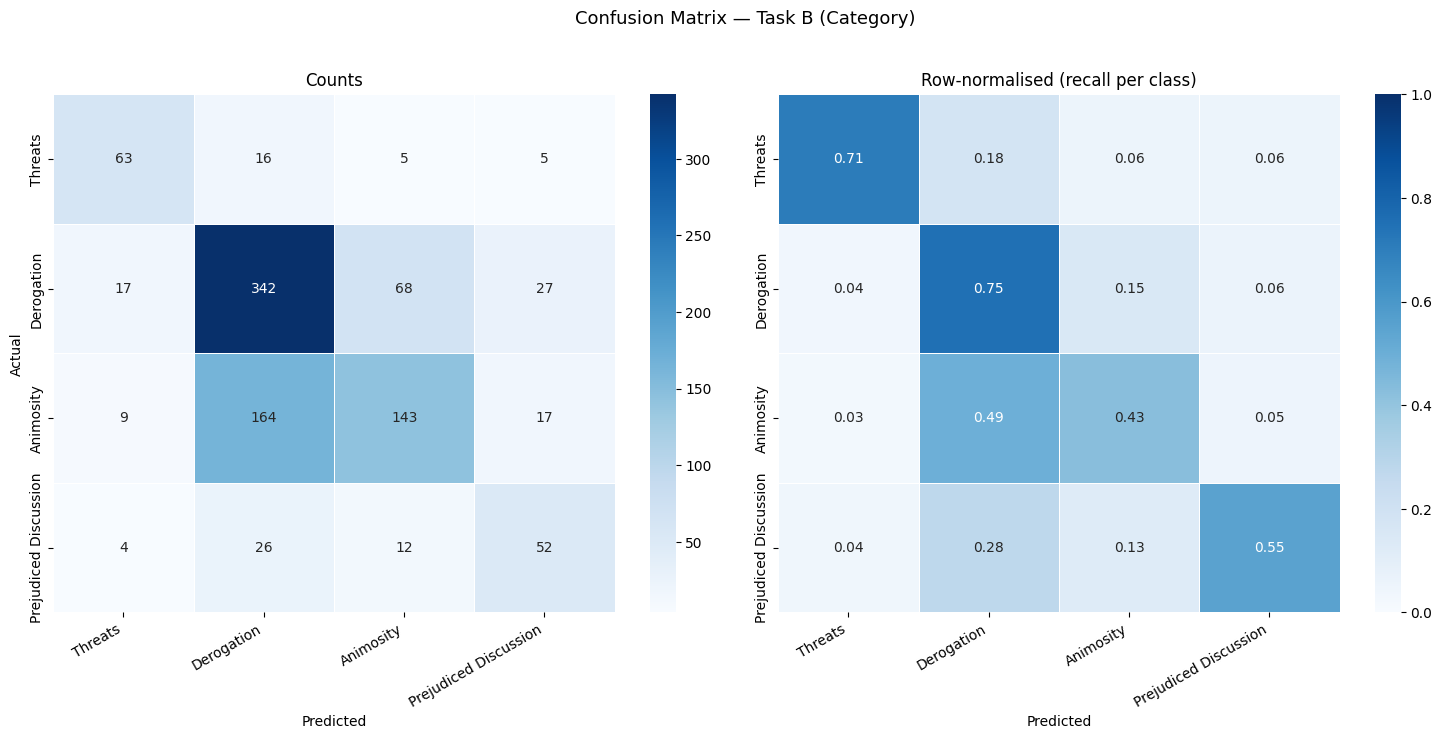

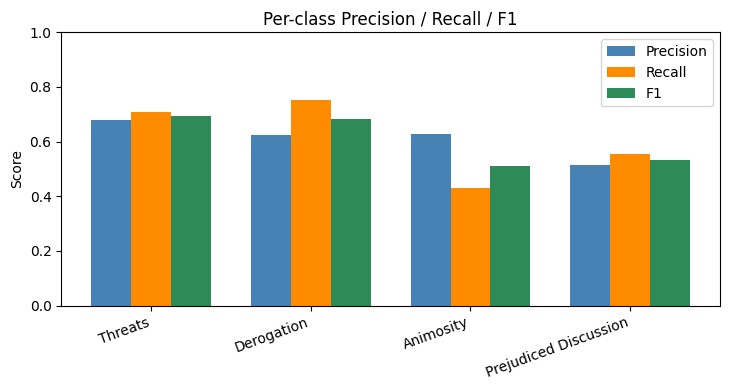


ERROR ANALYSIS

Total errors: 370 / 970 (38.1%)

Error rate per true class:


,class,errors,total,error_rate (%)
2,Animosity,190,333,57.1
3,Prejudiced Discussion,42,94,44.7
0,Threats,26,89,29.2
1,Derogation,112,454,24.7



Top confusion pairs (actual → predicted):


,actual,predicted,count
0,Animosity,Derogation,164
3,Derogation,Animosity,68
4,Derogation,Prejudiced Discussion,27
7,Prejudiced Discussion,Derogation,26
5,Derogation,Threats,17
1,Animosity,Prejudiced Discussion,17
10,Threats,Derogation,16
6,Prejudiced Discussion,Animosity,12
2,Animosity,Threats,9
9,Threats,Animosity,5


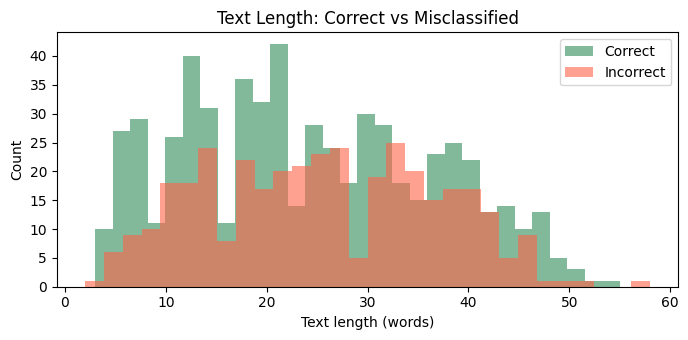


Sample misclassified examples:

  ✗ Actual: [Animosity]  →  Predicted: [Derogation]  (n = 164)
    • (0.77) lol that fat girl . black men cant catch up to us so they are angry . soo black men are angry because they are not marry
    • (0.86) real men aren't violent real women are if i said that on r/feminism i would be banned instantly and if i said it in real
    • (0.93) typical praising of women and bashing of men. they're so predictable. and dumb.

  ✗ Actual: [Derogation]  →  Predicted: [Animosity]  (n = 68)
    • (0.89) yes, normal women want to be dominated. social scientists call it female hypergamy. and it is why women make bad bosses 
    • (0.87) some, a very few men get a free and easy lay. if you are not sexually attractive, you don't get to be a horsie on the co
    • (0.87) that smile on her face that says "yup i can act like a total bitch and he still does things for me"

  ✗ Actual: [Derogation]  →  Predicted: [Prejudiced Discussion]  (n = 27)
    • (0.89) start looki

In [5]:
tf_category = run_transformer_category(state, device)